# Notebook 02 - Feature Engineering

Hasil akhir fase ini adalah feature store Parquet di `data/processed/`:
- `user_features.parquet` - 331K user, ~45 kolom (aktivitas, recency, tenure,
  affinity per genre, count per genre).
- `item_features.parquet` - 83K film, ~30 kolom (popularity bucket, avg/std
  rating, genre one-hot, dekade rilis).
- `genome_embedding.parquet` - 1 baris per film, kolom `embedding` berisi
  list 1128-dim (relevance tag-genome).
- `splits/train.parquet`, `splits/val.parquet`, `splits/test.parquet` -
  leave-last-2-out per user + feature temporal inline (hour, dow, movie_age).

Komputasi dikerjakan oleh `src/features.py`. Notebook ini memuat output
dan memverifikasi sanity: distribusi, missing-rate, korelasi sederhana,
serta ukuran file.


## 1. Setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150

FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
PROC = ROOT / "data" / "processed"

def savefig(name):
    out = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(out, bbox_inches="tight")
    print(f"  saved -> {out.relative_to(ROOT)}")


## 2. Muat feature store

In [2]:
user_f = pl.read_parquet(PROC / "user_features.parquet")
item_f = pl.read_parquet(PROC / "item_features.parquet")
genome = pl.read_parquet(PROC / "genome_embedding.parquet")
train = pl.scan_parquet(PROC / "splits" / "train.parquet")
val = pl.scan_parquet(PROC / "splits" / "val.parquet")
test = pl.scan_parquet(PROC / "splits" / "test.parquet")

print(f"user_features  : {user_f.shape} - {user_f.estimated_size('mb'):.0f} MB")
print(f"item_features  : {item_f.shape} - {item_f.estimated_size('mb'):.0f} MB")
print(f"genome_embed   : {genome.shape}  (embedding dim = {len(genome['embedding'][0])})")
print(f"train rows     : {train.select(pl.len()).collect().item():,}")
print(f"val rows       : {val.select(pl.len()).collect().item():,}")
print(f"test rows      : {test.select(pl.len()).collect().item():,}")


user_features  : (330975, 46) - 62 MB
item_features  : (83239, 31) - 8 MB
genome_embed   : (16376, 2)  (embedding dim = 1128)
train rows     : 32,713,650
val rows       : 559,256
test rows      : 559,256


## 3. User features

shape: (9, 47)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ userId    ┆ n_ratings ┆ mean_rati ┆ … ┆ affinity_ ┆ n_War     ┆ affinity_ ┆ n_Wester │
│ ---       ┆ ---       ┆ ---       ┆ ng        ┆   ┆ War       ┆ ---       ┆ Western   ┆ n        │
│ str       ┆ f64       ┆ f64       ┆ ---       ┆   ┆ ---       ┆ f64       ┆ ---       ┆ ---      │
│           ┆           ┆           ┆ f64       ┆   ┆ f64       ┆           ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 330975.0  ┆ 330975.0  ┆ 330975.0  ┆ … ┆ 237056.0  ┆ 237056.0  ┆ 158712.0  ┆ 158712.0 │
│ null_coun ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ … ┆ 93919.0   ┆ 93919.0   ┆ 172263.0  ┆ 172263.0 │
│ t         ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ mean      ┆ 165488.0  ┆ 102.21969 ┆ 3.696335  ┆ … ┆ 3.89866   ┆ 7.161384  

  saved -> reports\figures\16_user_feature_overview.png


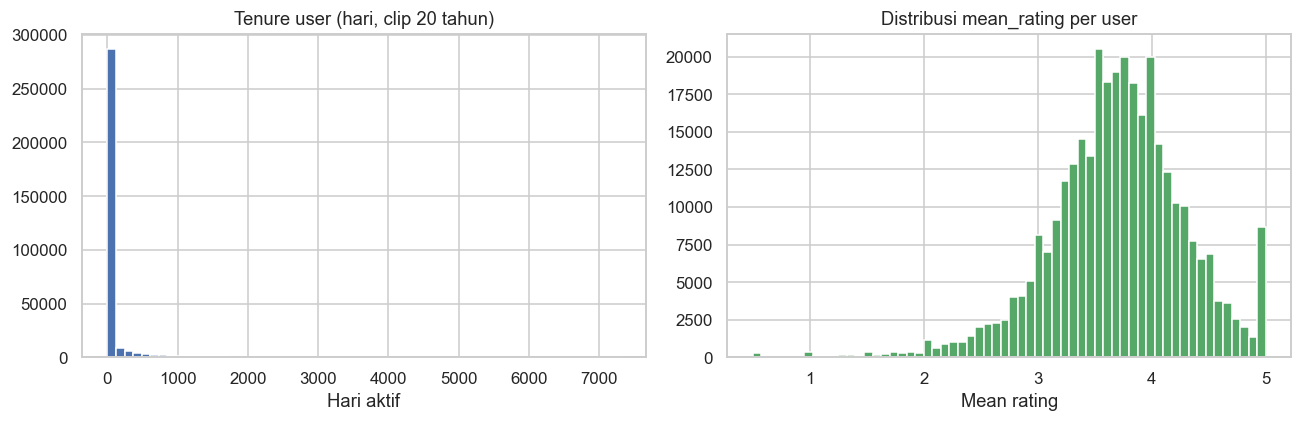

In [3]:
# Sanity user features
print(user_f.describe())
print()
print("Missing rate affinity_Drama :", user_f['affinity_Drama'].is_null().sum() / user_f.height)
print("Missing rate affinity_Film-Noir:", user_f['affinity_Film-Noir'].is_null().sum() / user_f.height)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.clip(user_f['tenure_days'].to_numpy(), 0, 365*20), bins=60, color='#4C72B0')
axes[0].set_title('Tenure user (hari, clip 20 tahun)')
axes[0].set_xlabel('Hari aktif')

axes[1].hist(user_f['mean_rating'].drop_nulls().to_numpy(), bins=60, color='#55A868')
axes[1].set_title('Distribusi mean_rating per user')
axes[1].set_xlabel('Mean rating')
savefig('16_user_feature_overview.png')
plt.show()


## 4. Korelasi affinity genre

  saved -> reports\figures\17_user_affinity_corr.png


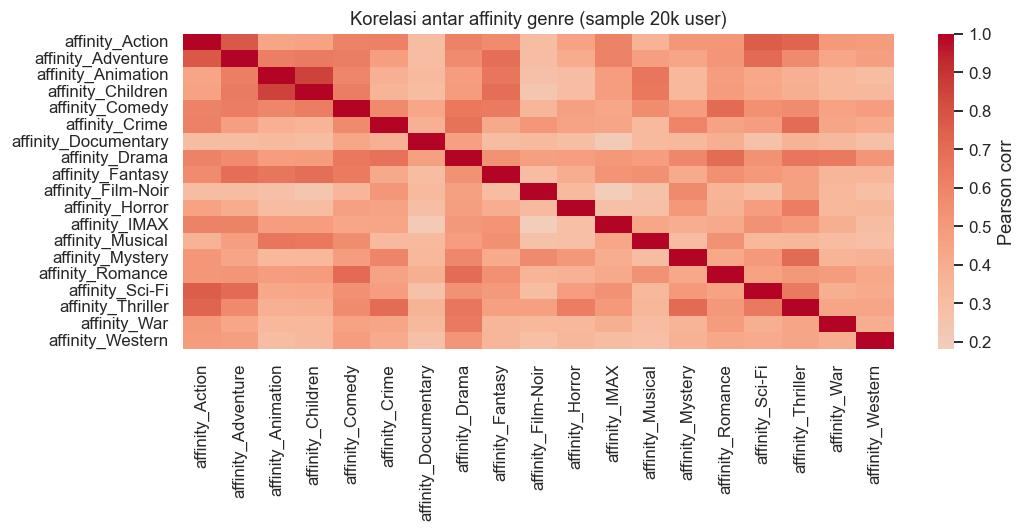

In [4]:
# Heatmap affinity per genre vs popularity bucket
aff_cols = [c for c in user_f.columns if c.startswith('affinity_')]
sample = user_f.sample(n=20000, seed=42)
mat = sample.select(aff_cols).to_pandas()
fig, ax = plt.subplots(figsize=(10, 5))
corr = mat.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax, cbar_kws={'label': 'Pearson corr'})
ax.set_title('Korelasi antar affinity genre (sample 20k user)')
savefig('17_user_affinity_corr.png')
plt.show()


## 5. Item features

  saved -> reports\figures\18_item_popularity_bucket.png


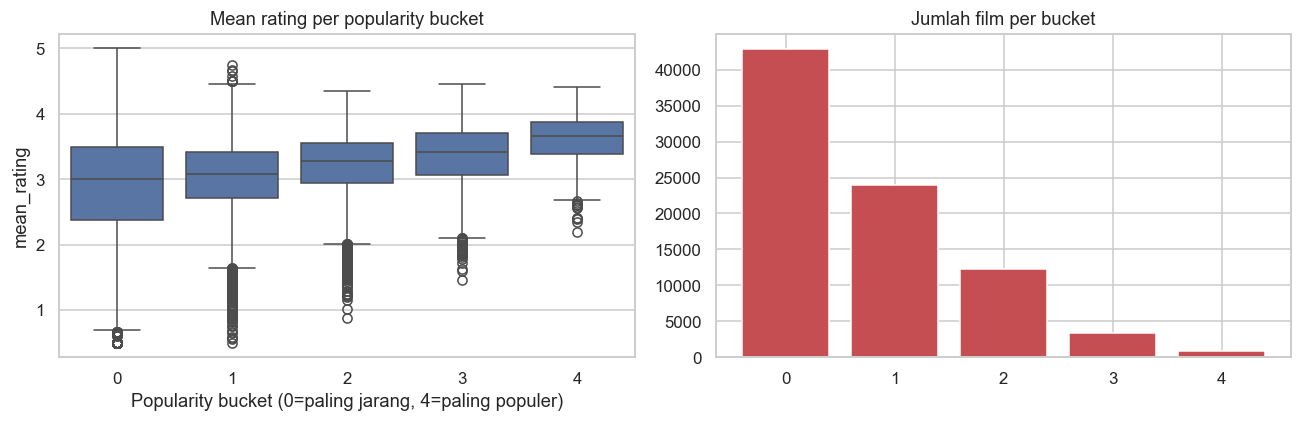

In [5]:
# Popularity bucket vs mean_rating
df = item_f.select(['popularity_bucket', 'mean_rating', 'n_ratings']).to_pandas()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x='popularity_bucket', y='mean_rating', ax=axes[0])
axes[0].set_title('Mean rating per popularity bucket')
axes[0].set_xlabel('Popularity bucket (0=paling jarang, 4=paling populer)')

bucket_count = df['popularity_bucket'].value_counts().sort_index()
axes[1].bar(bucket_count.index.astype(str), bucket_count.values, color='#C44E52')
axes[1].set_title('Jumlah film per bucket')
savefig('18_item_popularity_bucket.png')
plt.show()


## 6. Tag-genome embedding

  saved -> reports\figures\19_genome_embedding_stats.png


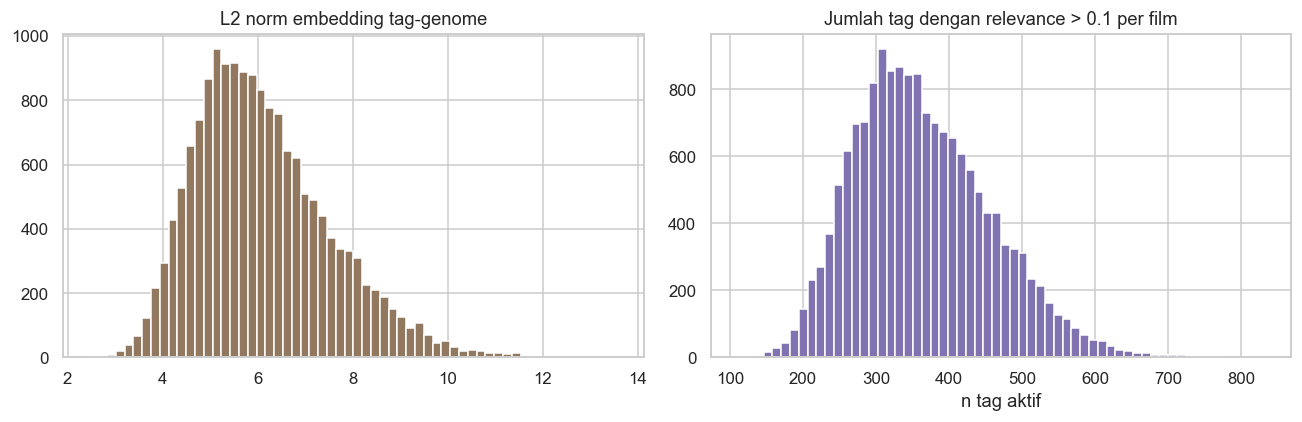

Film dengan embedding: 16,376
Dimensi embedding    : 1128
Mean L2 norm         : 6.105
Mean n_active_tags   : 364.5


In [6]:
# Norma embedding genome (indikasi richness tag per film)
emb = np.asarray(genome['embedding'].to_list(), dtype=np.float32)
norms = np.linalg.norm(emb, axis=1)
nnz = (emb > 0.1).sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(norms, bins=60, color='#937860')
axes[0].set_title('L2 norm embedding tag-genome')
axes[1].hist(nnz, bins=60, color='#8172B2')
axes[1].set_title('Jumlah tag dengan relevance > 0.1 per film')
axes[1].set_xlabel('n tag aktif')
savefig('19_genome_embedding_stats.png')
plt.show()

print(f"Film dengan embedding: {emb.shape[0]:,}")
print(f"Dimensi embedding    : {emb.shape[1]}")
print(f"Mean L2 norm         : {norms.mean():.3f}")
print(f"Mean n_active_tags   : {nnz.mean():.1f}")


## 7. Time-based split

  saved -> reports\figures\20_split_per_year.png


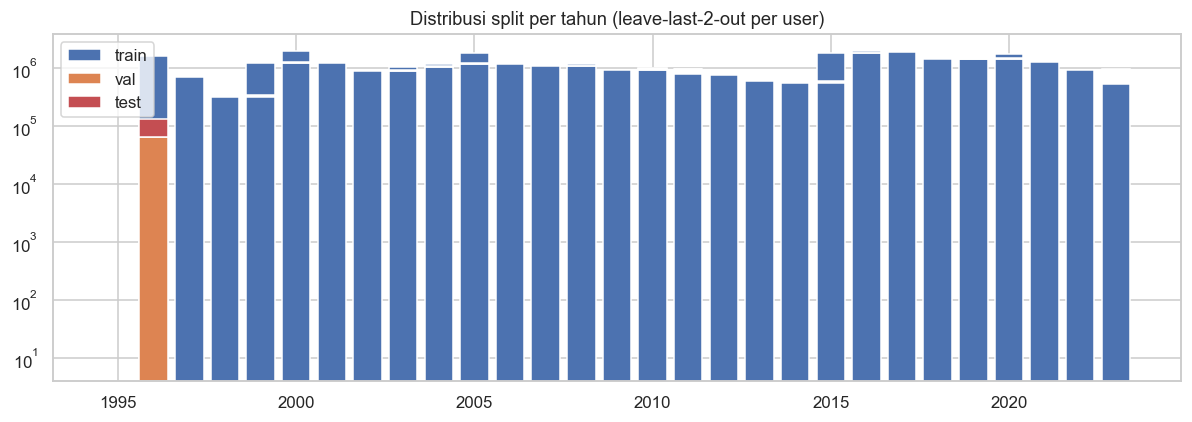

Test user unik       : 279,628
Val user unik        : 279,628


In [7]:
# Ringkasan split berbasis timestamp
tr = train.group_by(pl.col('rated_at').dt.year()).agg(pl.len().alias('n')).sort('rated_at').collect().to_pandas()
va = val.group_by(pl.col('rated_at').dt.year()).agg(pl.len().alias('n')).sort('rated_at').collect().to_pandas()
te = test.group_by(pl.col('rated_at').dt.year()).agg(pl.len().alias('n')).sort('rated_at').collect().to_pandas()

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(tr['rated_at'], tr['n'], label='train', color='#4C72B0')
ax.bar(va['rated_at'], va['n'], bottom=tr['n'].reindex(va.index, fill_value=0), label='val', color='#DD8452')
ax.bar(te['rated_at'], te['n'], bottom=(tr['n'].reindex(te.index, fill_value=0)
                                        + va['n'].reindex(te.index, fill_value=0)),
       label='test', color='#C44E52')
ax.set_yscale('log')
ax.set_title('Distribusi split per tahun (leave-last-2-out per user)')
ax.legend()
savefig('20_split_per_year.png')
plt.show()

print(f"Test user unik       : {test.select(pl.col('userId').n_unique()).collect().item():,}")
print(f"Val user unik        : {val.select(pl.col('userId').n_unique()).collect().item():,}")


## 8. Fitur temporal di train split

  saved -> reports\figures\21_temporal_features_train_sample.png


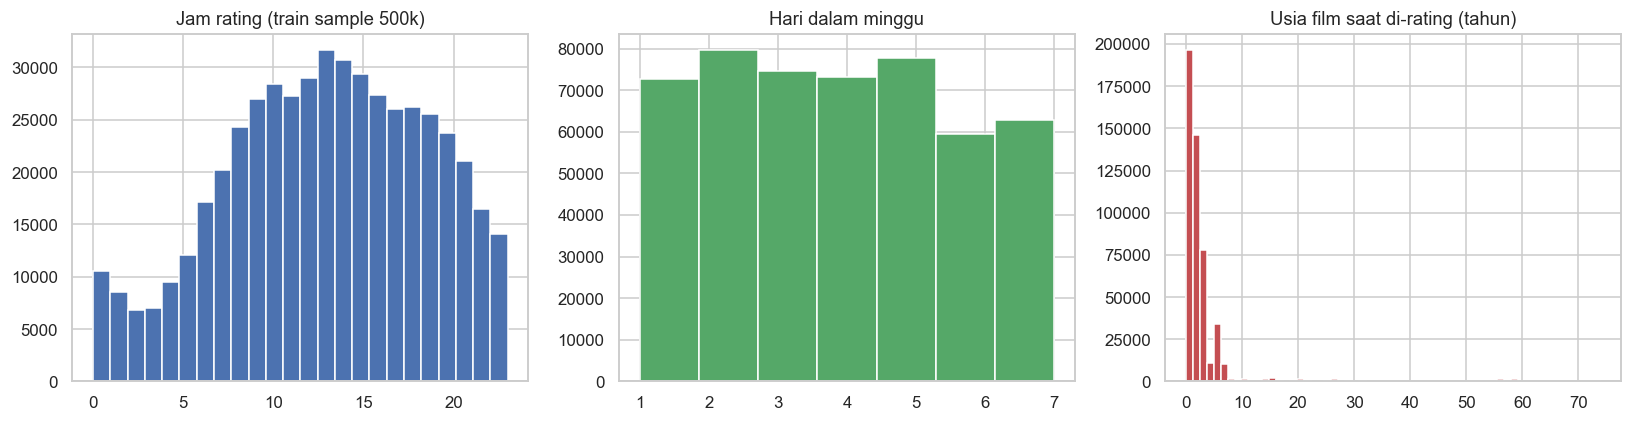

In [8]:
# Verifikasi kolom temporal di split
sample = train.head(500000).collect()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(sample['hour'].to_numpy(), bins=24, color='#4C72B0')
axes[0].set_title('Jam rating (train sample 500k)')
axes[1].hist(sample['dow'].to_numpy(), bins=7, color='#55A868')
axes[1].set_title('Hari dalam minggu')
age = sample['movie_age'].drop_nulls().to_numpy()
age = age[(age >= 0) & (age <= 80)]
axes[2].hist(age, bins=60, color='#C44E52')
axes[2].set_title('Usia film saat di-rating (tahun)')
savefig('21_temporal_features_train_sample.png')
plt.show()


## Ringkasan Feature Store

- User features siap untuk model berbasis konten (content-based, hybrid) dan
  sebagai side-information bagi factorization (ALS + fitur eksplisit).
- Item features siap untuk reranking heuristik (popularity bucket, dekade)
  dan sebagai input content-based similarity bersama embedding genome.
- Genome embedding dapat langsung di-ingest ke FAISS untuk retrieval semantik.
- Split `train/val/test` sudah bebas target-leakage (leave-last-2-out per user)
  dan membawa fitur temporal (`hour`, `dow`, `movie_age`) sehingga bisa dipakai
  oleh sequence model (Fase 4) maupun gradient boosting (opsional).
